# Iris_Neural_Network_From_Scratch

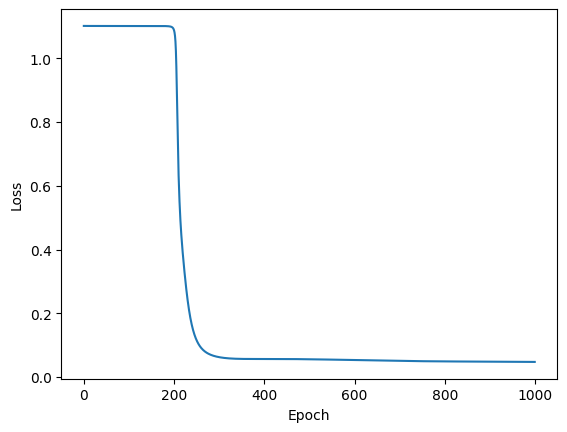

Misclassified:
Features: [0.66666667 0.41666667 0.6779661  0.66666667] Pred: Iris-virginica True: Iris-versicolor
Features: [0.47222222 0.29166667 0.69491525 0.625     ] Pred: Iris-virginica True: Iris-versicolor
Accuracy: 93.33333333333333


In [6]:
import numpy as np
import matplotlib.pyplot as plt

data=np.genfromtxt('Iris.csv',delimiter=',',dtype=str,skip_header=1)
X=data[:,1:5].astype(float)
labels=data[:,-1]
classes=np.unique(labels)
mapping={c:i for i,c in enumerate(classes)}
y=np.eye(3)[[mapping[l] for l in labels]]

X=(X-X.min(0))/(X.max(0)-X.min(0))
idx=np.random.permutation(len(X))
X,y=X[idx],y[idx]
Xtr,Xte=X[:120],X[120:]
ytr,yte=y[:120],y[120:]

W1=np.random.randn(10,4)*0.01;b1=np.zeros((10,1))
W2=np.random.randn(5,10)*0.01;b2=np.zeros((5,1))
W3=np.random.randn(3,5)*0.01;b3=np.zeros((3,1))

relu=lambda z: np.maximum(0,z)
drelu=lambda z:(z>0).astype(float)
def softmax(z):
 z=z-z.max()
 e=np.exp(z)
 return e/e.sum()

lr=0.01
losses=[]
for epoch in range(1000):
 loss=0
 for xi,yi in zip(Xtr,ytr):
  x=xi.reshape(-1,1);t=yi.reshape(-1,1)
  Z1=W1@x+b1;A1=relu(Z1)
  Z2=W2@A1+b2;A2=relu(Z2)
  Z3=W3@A2+b3;A3=softmax(Z3)
  loss+=-np.sum(t*np.log(A3+1e-12))
  dZ3=A3-t
  dW3=dZ3@A2.T; db3=dZ3
  dZ2=(W3.T@dZ3)*drelu(Z2)
  dW2=dZ2@A1.T; db2=dZ2
  dZ1=(W2.T@dZ2)*drelu(Z1)
  dW1=dZ1@x.T; db1=dZ1
  W3-=lr*dW3;b3-=lr*db3
  W2-=lr*dW2;b2-=lr*db2
  W1-=lr*dW1;b1-=lr*db1
 losses.append(loss/len(Xtr))
plt.plot(losses);plt.xlabel('Epoch');plt.ylabel('Loss');plt.show()

correct=0
print('Misclassified:')
for xi,yi in zip(Xte,yte):
 x=xi.reshape(-1,1)
 A1=relu(W1@x+b1)
 A2=relu(W2@A1+b2)
 p=softmax(W3@A2+b3)
 pred=np.argmax(p);true=np.argmax(yi)
 if pred==true: correct+=1
 else:
  print('Features:',xi,'Pred:',classes[pred],'True:',classes[true])
print('Accuracy:',correct/len(Xte)*100)


The misclassified samples likely have feature values that overlap between different Iris species, making them difficult to distinguish. Since the network is relatively small and trained on a limited dataset of only 150 samples, it may not capture all subtle decision boundaries, leading to a few incorrect predictions.